## <span style="color:green">Solutions</span>

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import numpy as np

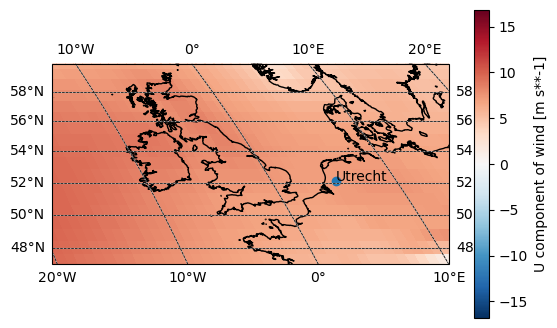

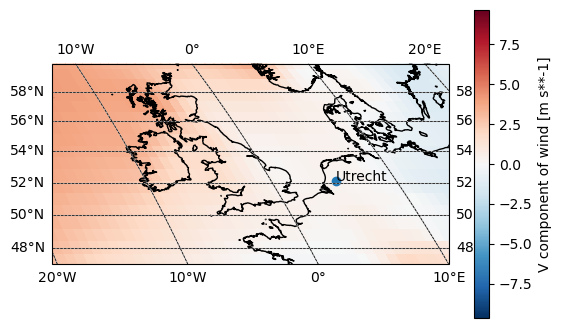

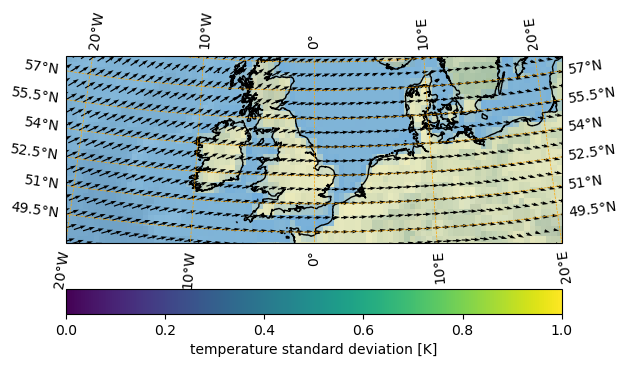

In [8]:
# 1. Load the ERA5 wind data taken at different heights (heights are in hPa). 
# Plot the u- and v-components at a certain height and at a certian time.
# mark and label Utrecht in two projections of your choice that are not PlateCarree. 
# Use both xarray's built-in plotting and the matplotlib approach (see above).
# Use the u- and- components to create a vector plot (quiver) over `stock_img()`. 
# Hint: use the command scale to make sure that the arrows are visibile, 
# the scale will probablly set to abougt 400.

ds = xr.tutorial.open_dataset(name='eraint_uvz')

fig = plt.figure(figsize=(6.4,4))
p=ds.isel(month=0,level=2).u.plot(subplot_kws=dict(projection=ccrs.EqualEarth(central_longitude=-90), facecolor="lightgray"),
    transform=ccrs.PlateCarree())
ax = p.axes
ax.coastlines()
ax.gridlines()
ax.set_extent([-12,10,47,60])
ax.set_title('')
ax.scatter(5.12, 52.091, transform=ccrs.PlateCarree())
ax.text(5.12, 52.091, 'Utrecht', transform=ccrs.PlateCarree())
ax.gridlines(color='black', lw=.5, draw_labels=True, linestyle='--')
plt.savefig('figures/4a11')

fig = plt.figure(figsize=(6.4,4))
p=ds.isel(month=0,level=2).v.plot(subplot_kws=dict(projection=ccrs.EqualEarth(central_longitude=-90), facecolor="lightgray"),
    transform=ccrs.PlateCarree())
ax = p.axes
ax.coastlines()
ax.gridlines()
ax.set_extent([-12,10,47,60])
ax.set_title('')
ax.scatter(5.12, 52.091, transform=ccrs.PlateCarree())
ax.text(5.12, 52.091, 'Utrecht', transform=ccrs.PlateCarree())
ax.gridlines(color='black', lw=.5, draw_labels=True, linestyle='--')
plt.savefig('figures/4a12')

fig = plt.figure(figsize=(6.4,4))
ax = plt.axes(projection=ccrs.EquidistantConic(standard_parallels=50.0))
ax.stock_img()
ax.set_extent([-20,20,48,58])
lons, lats = np.meshgrid(ds.longitude, ds.latitude)
Uu = np.array(ds.isel(month=0,level=2).u)
Vv = np.array(ds.isel(month=0,level=2).v)
#Uu, Vv = np.meshgrid(ds.isel(month=0,level=0).u, ds.isel(month=0,level=0).v)
im = ax.quiver(lons, lats, Uu, Vv, transform=ccrs.PlateCarree(),scale=4E2)
plt.colorbar(im, ax=ax, orientation='horizontal', label='temperature standard deviation [K]')
ax.coastlines()
ax.gridlines(color='orange', lw=.5, draw_labels=True, linestyle='--')
plt.savefig('figures/4a13')

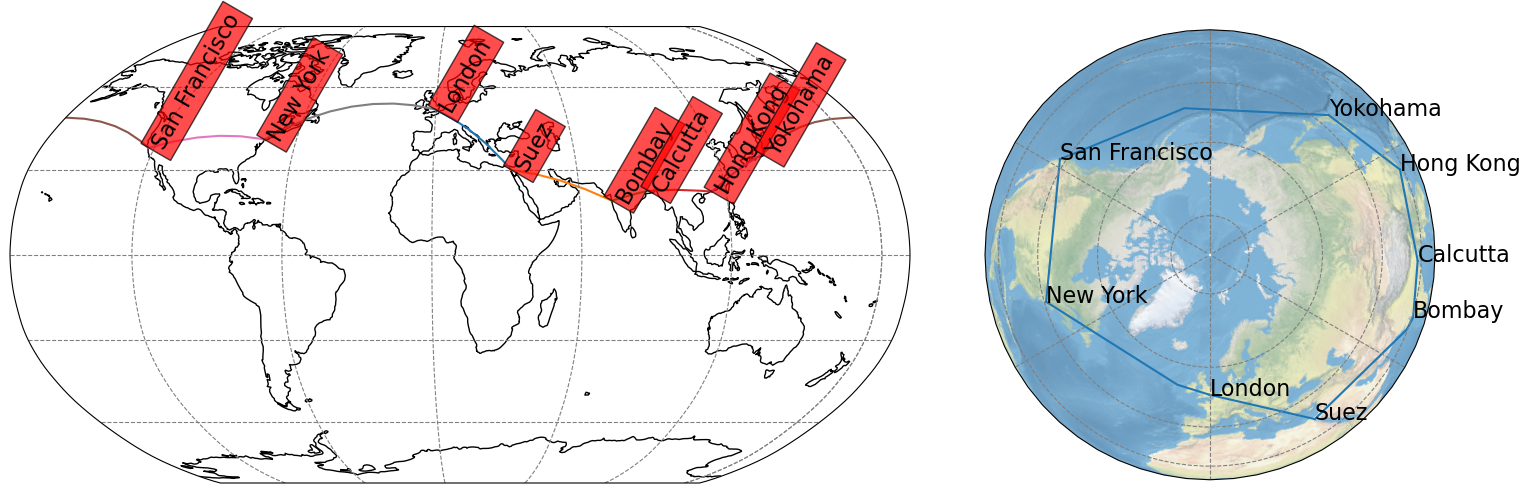

In [10]:
# 2. Recreate the travel map of Phileas Fogg of Jules Verne's 
# _Around the World in Eighty Days_ using geodetics (true shortest paths) 
# and marking the cities as in the Wikipedia article:
#  A. Recreate the journey on a Robinson projection.
#  B. Phileas never left the Northern Hemisphere (and thus did not truly 
#     circumnavigate the Earth), so we can plot the full journey
#     in a projection centered around the North Pole.

places = {'London': (-0.1276474, 51.5073219),
          'Suez': (32.537086, 29.974498),
          'Bombay': (72.8882172, 19.1334321),
          'Calcutta': (88.3476023, 22.5677459),
          'Hong Kong': (114.1628131, 22.2793278),
          'Yokohama': (139.636768, 35.444991),
          'San Francisco': (-122.4629897, 37.7647993),
          'New York': (-73.9866136, 40.7306458)}
cities = list(places.keys())

fig = plt.figure(figsize=(15,10))
ax1 = fig.add_axes([0,0,.6,1], projection=ccrs.Robinson(central_longitude=11.25))
ax2 = fig.add_axes([.65,0,.3,1], projection=ccrs.Orthographic(central_latitude=90))
ax1.set_global()

ax2.stock_img()
ax1.coastlines()
for ax in [ax1, ax2]:
    ax.gridlines(color='gray', linestyle='--')
for i in range(len(cities)):
    city1 = cities[i]
    if i<len(cities)-1:
        city2 = cities[i+1]
    elif i==len(cities)-1:
        city2 = cities[0]
    lat1, lon1 = places[city1][1], places[city1][0]
    lat2, lon2 = places[city2][1], places[city2][0]
    ax1.text(lon1, lat1, city1, rotation=60, transform=ccrs.PlateCarree(),
             fontsize=16, bbox={'facecolor':'red', 'alpha':.7})
    ax1.plot([lon1,lon2],[lat1,lat2], transform=ccrs.Geodetic())
    
    ax2.plot([lon1,lon2],[lat1,lat2], c='C0', transform=ccrs.Geodetic())
    ax2.text(lon1, lat1, city1, transform=ccrs.PlateCarree(), fontsize=16)

plt.savefig('figures/4a2',bbox_inches='tight')